<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
N_vals = np.arange(10, 201, 10)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))


In [2]:
dt = 0.02
gamma = 0.005
lam = 0.5

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi, steps=250):
    for _ in range(steps):
        phi = phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3)
    return phi

def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

stability = []
for N in N_vals:
    centers = np.linspace(0, 2*np.pi, N, endpoint=False)
    phi0 = sum(gaussian(c, sigma, A) for c in centers)
    phi_final = evolve(phi0.copy())
    stability.append(correlation(phi_final, phi0))


/tmp/ipython-input-1494254727.py:10: RuntimeWarning: overflow encountered in power
  phi = phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3)
/tmp/ipython-input-1494254727.py:6: RuntimeWarning: invalid value encountered in subtract
  return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)
/tmp/ipython-input-1494254727.py:6: RuntimeWarning: invalid value encountered in add
  return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)


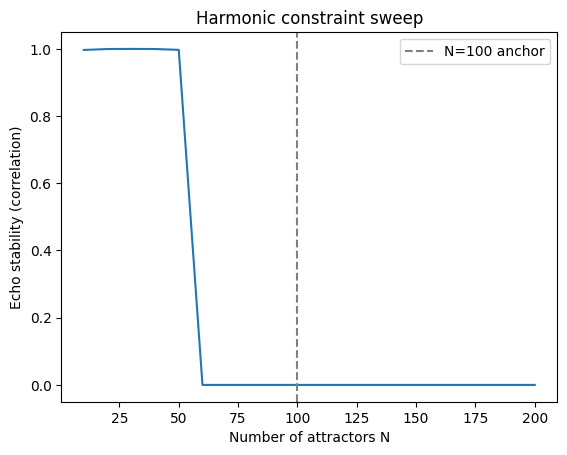

In [3]:
plt.plot(N_vals, stability)
plt.axvline(x=100, color='gray', linestyle='--', label="N=100 anchor")
plt.xlabel("Number of attractors N")
plt.ylabel("Echo stability (correlation)")
plt.title("Harmonic constraint sweep")
plt.legend()
plt.show()
